## 1. Data Generation/Augmentation

The dataset exhibits a highly non-uniform distribution across different parameter combinations (k, m). Since the test set is generated by applying small random perturbations (±1 or ±2) to existing training samples, its distribution is expected to closely mirror that of the training data.

To better align the model with this target distribution, we adopt the following strategies:

1.Generate additional synthetic samples that follow the same (k, m) proportions as the teacher dataset;

2.Apply local perturbations around existing samples to expand the dataset without altering the overall distribution.

These strategies help the model generalize more effectively to the test set, whose structure and distribution closely resemble those of the training data. In total, around 40,000 samples were generated using CPU-based parallelization (runtime: 24.3 hours).

The following code has been run in a seperate python file. 
Do not run this in jupyter notebook.

In [ ]:
import numpy as np
import pickle, random, time, os
from itertools import combinations, product
from scipy.optimize import linprog
from joblib import Parallel, delayed
from tqdm import tqdm

def build_tau_inv(a: int, b: int, X, n: int, m: int) -> np.ndarray:
    X = sorted(set(X))
    tau_inv = np.empty(n, dtype=int)
    tau_inv[a] = 0
    for idx, val in enumerate(X, start=1):
        tau_inv[val] = idx
    tau_inv[b] = m
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for i, j in enumerate(Y, start=m + 1):
        tau_inv[j] = i
    return tau_inv

def solve_z_lp(a, b, m, X, psi, G):
    k, n = G.shape
    tau_i = build_tau_inv(a, b, X, n, m)
    s0 = psi[0]
    c = -s0 * G[:, a]

    A_ub, b_ub = [], []
    for j in X:
        sj = psi[tau_i[j]]
        A_ub.append(sj * G[:, j] - s0 * G[:, a])
        b_ub.append(0.0)
        A_ub.append(-sj * G[:, j])
        b_ub.append(-1.0)
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for j in Y:
        A_ub.append(G[:, j])
        b_ub.append(1.0)
        A_ub.append(-G[:, j])
        b_ub.append(1.0)

    A_ub = np.vstack(A_ub) if A_ub else np.zeros((0, k))
    b_ub = np.array(b_ub, dtype=float)
    A_eq = G[:, b].reshape(1, k)
    b_eq = np.array([1.0])
    bounds = [(None, None)] * k

    z = linprog(c=c, A_ub=A_ub, b_ub=b_ub,
                A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if z.status == 0:
        return -z.fun
    if z.status == 2:
        return 0.0
    if z.status == 3:
        return float('inf')
    return float('nan')

def m_height_calc(n, k, m, G):
    max_ = -np.inf
    for a in range(n):
        for b in range(n):
            if a == b:
                continue
            x = [i for i in range(n) if i not in (a, b)]
            for X in combinations(x, m - 1):
                for psi in product([-1, 1], repeat=m):
                    z = solve_z_lp(a, b, m, X, psi, G)
                    if z == float('inf'):
                        return float('inf')
                    if z > max_:
                        max_ = z
    return max_


#  Perturbation generator

def perturb_P(P, num_changes=3, delta=1):
    #randomly select position in P and add ±1
    P_new = P.copy()
    k, n_k = P.shape
    total = k * n_k
    idx = random.sample(range(total), min(num_changes, total))
    for i in idx:
        r, c = divmod(i, n_k)
        P_new[r, c] += random.choice([-delta, delta])
    return P_new

def Gen_one_augmented_sample(n, k, m, P):
    # generate a new sample（compute m_height after we add noise）
    P_new = perturb_P(P)
    G = np.hstack([np.eye(k), P_new])
    mh = m_height_calc(n, k, m, G)
    if np.isinf(mh) or np.isnan(mh):
        return None, mh
    return (n, k, m, P_new), mh


if __name__ == "__main__":
    start_time = time.time()

    # read teachers data
    with open("DS-3-Train-n_k_m_P", "rb") as f:
        teacher_nkmP = pickle.load(f)
    random.shuffle(teacher_nkmP)    #shuffle the teacher's dataset
    teacher_nkmP = teacher_nkmP[:40000]   #select 40000 samples

    print(f"Loaded and shuffled teacher dataset: {len(teacher_nkmP)} samples")

    # gen samples parallal
    def process_one(sample):
        n, k, m, P = sample
        nkmp_new, mh_new = Gen_one_augmented_sample(n, k, m, P)
        if nkmp_new is None:
            return None
        return (nkmp_new, mh_new)

    augmented_inputs, augmented_outputs = [], []
    batch_size = 5000
    total = len(teacher_nkmP)

    for batch_start in range(0, total, batch_size):
        batch_end = min(batch_start + batch_size, total)
        batch = teacher_nkmP[batch_start:batch_end]

        print(f"\n▶️ Generating samples {batch_start+1}–{batch_end} ...")
        results = Parallel(n_jobs=-1, backend="loky")(
            delayed(process_one)(sample) for sample in tqdm(batch)
        )

        for r in results:
            if r is not None:
                nkmp, mh = r
                augmented_inputs.append(nkmp)
                augmented_outputs.append(mh)

        # save for every batch
        with open(f"LP_inputs_partial_{batch_end}.pkl", "wb") as f:
            pickle.dump(augmented_inputs, f)
        with open(f"LP_outputs_partial_{batch_end}.pkl", "wb") as f:
            pickle.dump(augmented_outputs, f)

        elapsed = time.time() - start_time
        print(f"Saved {batch_end} samples. Time elapsed: {elapsed/60:.2f} min")

    print(f"\n Done. Total valid samples: {len(augmented_inputs)}")
    print(f"Total time: {(time.time()-start_time)/60:.2f} minutes")

    # save
    with open("LP_augmented_inputs.pkl", "wb") as f:
        pickle.dump(augmented_inputs, f)
    with open("LP_augmented_outputs.pkl", "wb") as f:
        pickle.dump(augmented_outputs, f)
    print(" Saved final LP_augmented_inputs.pkl / LP_augmented_outputs.pkl")




## 2. Models

### 2.1 Data import and train/test split

In [1]:
import numpy as np
import pickle
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from itertools import combinations, product
from scipy.optimize import linprog
from tqdm import tqdm
from scipy.stats import skew, kurtosis


In [2]:
teacher_input_file = 'DS-3-Train-n_k_m_P'
teacher_output_file = 'DS-3-Train-mHeights'
my_input_file = "LP_inputs_partial_40000.pkl"
my_output_file = "LP_outputs_partial_40000.pkl"


In [3]:
def load_data(input_file,output_file):
    with open(input_file,'rb') as f:
        nkmp = pickle.load(f)
    with open(output_file, 'rb') as f:
        mh = pickle.load(f)
    return nkmp, mh

In [4]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split

# load the given teacher dataset
teacher_nkmP, teacher_mh = load_data(teacher_input_file,teacher_output_file)

# split the teacher dataset
nkmP_train, nkmP_val, mh_train, mh_val = train_test_split(teacher_nkmP, teacher_mh, test_size=0.2, random_state=42)

my_nkmP, my_mh = load_data(my_input_file, my_output_file)

print(f"Teacher dataset total: {len(teacher_nkmP)}; split: Train={len(nkmP_train)}, Val={len(nkmP_val)}")

print(f"My dataset total: {len(my_nkmP)}")

Teacher dataset total: 56365; split: Train=45092, Val=11273
My dataset total: 38624


In [25]:
print(type(nkmP_train[0]), nkmP_train[0])
print(type(mh_train[0]), mh_train[0])


<class 'list'> [9, 4, 2, array([[ 34,  38, -28,  30, -31],
       [ 10,  -7,  29, -10, -21],
       [-10,   9, -21, -21,   2],
       [-17,  11,  25,  40,  15]])]
<class 'float'> 62.89162561576356


## 2.1 Transformer

In [10]:
def extract_P_features(P):
    P = np.asarray(P, dtype=np.float32)
    feats = []

    feats.append(np.mean(P))                       # mean
    feats.append(np.std(P))                        # std
    feats.append(np.max(P))                        # max
    feats.append(np.min(P))                        # min
    feats.append(np.median(P))                     # median
    feats.append(np.mean(np.abs(P)))               # mean absolute value
    feats.append(np.linalg.norm(P, 'fro'))         # Frobenius norm

    feats.append(np.mean(np.var(P, axis=0)))       # column-wise variance mean
    feats.append(np.mean(np.var(P, axis=1)))       # row-wise variance mean
    feats.append(np.std(np.var(P, axis=0)))        # column variance std
    feats.append(np.std(np.var(P, axis=1)))        # row variance std

    feats.append(skew(P.flatten()))                # skewness
    feats.append(kurtosis(P.flatten()))            # kurtosis
    feats.append(np.linalg.norm(P, 1))             # L1 norm
    feats.append(np.linalg.norm(P, np.inf))        # max–row–sum norm
    feats.append(np.max(P) / (np.abs(np.min(P)) + 1e-8))     # max/min ratio
    feats.append(np.std(P) / (np.abs(np.mean(P)) + 1e-8))    # coeff of variation

    try:
        s = np.linalg.svd(P, compute_uv=False)
        s_sorted = np.sort(s)[::-1]
        feats.append(s_sorted[0])                  # largest singular value
        feats.append(np.sum(s_sorted))             # spectral sum (energy)
        feats.append(np.std(s_sorted))             # singular value spread
    except np.linalg.LinAlgError:
        feats += [0.0, 0.0, 0.0]                   # fallback for degenerate P

    # pad to square for symmetry diff
    if P.shape[0] != P.shape[1]:
        pad = np.zeros((max(P.shape), max(P.shape)), dtype=np.float32)
        pad[:P.shape[0], :P.shape[1]] = P
        P_square = pad
    else:
        P_square = P

    feats.append(np.mean(np.abs(P_square - P_square.T)))     # asymmetry measure
    feats.append(np.sum(np.abs(P) < 1e-2) / P.size)          # sparsity ratio

    return feats


In [12]:
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

max_k = 6    # max rows, defined in project
max_feat = 5 # max columns, n - k (n = 9,k=4,5,6), since 1 row is a token, we have max 5-dim embedding

# This function transforms P with different shapes into the same one. and make output into log2 form
def preprocessing_transformer(inputs, outputs):

    P_list, mask_list, scalars_list, y_list = [], [], [], []

    for (n, k, m, P), mh in tqdm(zip(inputs, outputs),total=len(inputs)):

        k_i, feat_i = P.shape  # P: (k, n - k)

        # pad rows & columns to shape(max_k, max_feat)
        P_pad = np.zeros((max_k, max_feat), dtype=np.float32)
        P_pad[:k_i, :feat_i] = P

        # mask for valid tokens (rows)
        mask = np.zeros(max_k, dtype=np.float32)
        mask[:k_i] = 1.0 
        # why the mask only record which rows are padded?
        #Because attention only cares about the relation between tokens

        P_feats = extract_P_features(P) # concat into scalars or not? Which behaves better?
        scalars = np.array([ n,k, m] + P_feats , dtype=np.float32)
        
        y_val = np.log2(mh) #transfer to log2

        P_list.append(P_pad)

        mask_list.append(mask)
        scalars_list.append(scalars)
        y_list.append(y_val)

    return (
        np.array(P_list, dtype=np.float32),       # (N, max_k, max_feat)
        np.array(mask_list, dtype=np.float32),    # (N, max_k)
        np.array(scalars_list, dtype=np.float32), # (N, 3)
        np.array(y_list, dtype=np.float32)
        )


In [35]:
P_train_teacher, mask_train_teacher, scal_train_teacher, y_train_teacher = preprocessing_transformer(nkmP_train, mh_train)

P_val_teacher, mask_val_teacher, scal_val_teacher, y_val_teacher = preprocessing_transformer(nkmP_val, mh_val)


# my dataset are only for training, not validation
P_my, mask_my, scal_my, y_my  = preprocessing_transformer(my_nkmP, my_mh)


100%|███████████████████████████████████| 38624/38624 [00:13<00:00, 2929.45it/s]


In [36]:
print(type(nkmP_train[0]), nkmP_train[0])
print(type(mh_train[0]), mh_train[0])


<class 'list'> [9, 4, 2, array([[ 34,  38, -28,  30, -31],
       [ 10,  -7,  29, -10, -21],
       [-10,   9, -21, -21,   2],
       [-17,  11,  25,  40,  15]])]
<class 'float'> 62.89162561576356


In [37]:

P_train = np.concatenate([P_train_teacher, P_my], axis=0)
mask_train = np.concatenate([mask_train_teacher, mask_my], axis=0)
scal_train = np.concatenate([scal_train_teacher, scal_my], axis=0)
y_train = np.concatenate([y_train_teacher, y_my], axis=0)

P_val = P_val_teacher
mask_val = mask_val_teacher
scal_val = scal_val_teacher
y_val = y_val_teacher

print("\nFINAL SHAPES (for Transformer):")
print(f"P_train:   {P_train.shape}")
print(f"mask_train:{mask_train.shape}")
print(f"scal_train:{scal_train.shape}")
print(f"y_train:   {y_train.shape}")

print(f"P_val:     {P_val.shape}")
print(f"mask_val:  {mask_val.shape}")
print(f"scal_val:  {scal_val.shape}")
print(f"y_val:     {y_val.shape}")



FINAL SHAPES (for Transformer):
P_train:   (83716, 6, 5)
mask_train:(83716, 6)
scal_train:(83716, 25)
y_train:   (83716,)
P_val:     (11273, 6, 5)
mask_val:  (11273, 6)
scal_val:  (11273, 25)
y_val:     (11273,)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers
@tf.keras.utils.register_keras_serializable()
#this embd layer only has bias
class PosEmbd(layers.Layer):
    def __init__(self, max_k, embed_dim, **kwargs):
        super().__init__(**kwargs)   #necessary！If we write our own init, parent __init__ will not be run automatically
        self.max_k = max_k
        self.embed_dim = embed_dim
        #add trainable weight into the layer
        self.pos_emb = self.add_weight(
            shape=(max_k, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_emb")
        
#create a trainable layer, we should identify in which position. For example: the first token should add embd[0]
# 'get_config' and 'from_config' are necessary if we want to save and reload the model
    def call(self, x):
        # x: (batch, max_k, embed_dim) broadcasting，we can add self.pos_emb into every x sample
        return x + self.pos_emb

    #tell keras this layer has which initialized parameters, these are needed to create this layer
    def get_config(self):
        config = super().get_config()
        config.update({
            "max_k": self.max_k,
            "embed_dim": self.embed_dim,
        })
        return config
        
    @classmethod
    def from_config(cls, config):
        return cls(**config)
        
# ** is unpacking the dict        
#keras save model, it needs to save hyperparameters for every layer, they are stored in a dict called 'config'

NOTE: We don’t use sinusoidal positional encoding because data (rows of matrix P) is not a true sequential signal like text or audio. No natural order or relative distance is meaningful between rows, so sinusoidal encoding would inject the wrong inductive bias.
A learnable positional embedding lets the model learn for itself what each row position means, which works much better for structured matrices like P.

The following block is a standart encoder block: x → Multi-head Attention → Add & Norm → FeedForward → Add & Norm


In [29]:
# there are 2 projections in multihead attention, 1,input embd -> q.k.v, 2. output: multi head->original dim
# both of them shared weights
@tf.keras.utils.register_keras_serializable()
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1,**kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
       
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )  # concat, (batch, max_k, 16 * num_heads) -> output projection (dense layer) -> (batch, max_k, 16 )

        """
        FFN is tokenwise
        dense1:intput:embd_dim, output:ff_dim
        dense2:in: ff_dim, out:embd_dim,no activation. since this is a linear projection
        """
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6) #avoid / 0
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
   #only have dropout，batchnorm is in training
    def call(self, x, mask = None, training=False):#when model.fit,training will be set to True  automatically
        #we should set False as default, since model.fit will cover it
        attn_output = self.att(x, x, attention_mask = mask) # 3 inputs: query,value(key = value)
        #residual dropout
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    '''
    In order to save a custom layer inside a keras.Model, we must implement get_config() so Keras knows 
    how to serialize the layer’s initialization parameters.
    config.update() is used to add our custom arguments (like embed_dim, num_heads, etc.) 
    into the configuration dictionary so the layer can be correctly reconstructed during load_model().
   '''
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config
        
    @classmethod
    def from_config(cls, config):
        return cls(**config)
                              


In [31]:
@tf.keras.utils.register_keras_serializable()
class MaskExpandLayer(layers.Layer):
    def call(self, m):
        return tf.cast(m[:, tf.newaxis, tf.newaxis, :], tf.bool)

    def get_config(self): #although we do not have any hyperparameters, we'd better write get_config ?
        return super().get_config()



We distinguish between operations that need to be implemented as Keras layers and those that do not. 
Structural transformations (e.g., shape-changing operations like masking) must be defined as layers 
to be properly tracked, while simple element-wise operations (e.g., addition, multiplication) can be used directly.
a = tf.keras.Input(shape=(10,))
b = tf.keras.Input(shape=(20,))
x = tf.concat([a, b], axis=-1)
model = tf.keras.Model([a, b], x)


In [43]:
import keras.ops as ops
#attention: calc the mean for every feature
scalar_norm_layer = layers.Normalization(axis=-1)
scalar_norm_layer.adapt(scal_train) 

# P → Dense → LayerNorm → PosEmbedding → Transformer × 3 → Masked Pooling → concat scalar → MLP → y

def build_transformer_model(max_k, max_feat, embed_dim=64, num_heads=4, ff_dim=128):
    
    # we have three inputs:
    P_input = keras.Input(shape=(max_k, max_feat), name="P_matrix")
    mask_input = keras.Input(shape=(max_k,), name="mask")
    scalar_dim = scal_train.shape[1]   
    
    scalar_input = keras.Input(shape=(scalar_dim,), name="scalars")
    # [n, k, m, P_feats]

    # A linear projection is applied to each token (i.e., each row of P).
#Since Dense layers operate on the last dimension of the input, the input does not need to be flattened into a 1D vector.
    x = layers.Dense(embed_dim)(P_input) 
    x = layers.LayerNormalization()(x) #transformer sensitive to scale
    #if normalization，default var=1,mean = 0,otherwise adapt,default by last dimension
  
    x = PosEmbd(max_k, embed_dim)(x) #token_embd + pos_embd

    mask_layer = MaskExpandLayer()
    attn_mask = mask_layer(mask_input)

    for _ in range(3):
        x = TransformerEncoder(embed_dim, num_heads, ff_dim)(x, mask=attn_mask)

    mask_exp = tf.expand_dims(mask_input, axis=-1)  # (batch, max_k, 1)
    x_masked = x * mask_exp

    sum_x = ops.sum(x_masked, axis=1) #(batch, embed_dim)
    sum_mask = ops.sum(mask_exp, axis=1) #tf.reduce_sum

    pooled = sum_x / (sum_mask + 1e-6)

    scalar_norm = scalar_norm_layer(scalar_input) 
 
    
    #  Concatenate transformer embedding + scalar features 

    final_feat = layers.Concatenate()([pooled, scalar_norm])
   
    out = layers.Dense(128, activation="relu")(final_feat)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(1)(out)

    model = keras.Model(inputs=[P_input, mask_input, scalar_input],outputs=out)
    
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = 2e-4),
        loss="mse",
        metrics=["mae"])

    return model


In [44]:
print(P_train.shape)  
print(mask_train.shape)
print(scal_train.shape)


(83716, 6, 5)
(83716, 6)
(83716, 25)


In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,   
    restore_best_weights=True)

In [46]:
model = build_transformer_model(max_k,max_feat)

history = model.fit(
    {"P_matrix": P_train, "mask": mask_train, "scalars": scal_train},y_train,
    validation_data=({"P_matrix": P_val, "mask": mask_val, "scalars": scal_val},y_val),
    epochs=50,
    batch_size=64,
    callbacks = early_stop
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_2' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1309/1309 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 5.3922 - mae: 1.6580 - val_loss: 1.7110 - val_mae: 0.9826
Epoch 2/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 2.3450 - mae: 1.1468 - val_loss: 1.3242 - val_mae: 0.8447
Epoch 3/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - loss: 1.9530 - mae: 1.0336 - val_loss: 1.1408 - val_mae: 0.7453
Epoch 4/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - loss: 1.7755 - mae: 0.9848 - val_loss: 1.0388 - val_mae: 0.7227
Epoch 5/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - loss: 1.6939 - mae: 0.9563 - val_loss: 1.0048 - val_mae: 0.6902
Epoch 6/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - loss: 1.6465 - mae: 0.9391 - val_loss: 1.0039 - val_mae: 0.7132
Epoch 7/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 1.6125 - mae: 0.9275 - val_loss: 0.9371 - val_mae: 0.6642
Epoch 8/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 1.5886 - mae: 0.9179 - val_loss: 0.9396 - val_mae: 0.6795
Epoch 9/50
1309/1309 ━━━━━━━━━━━━━━

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


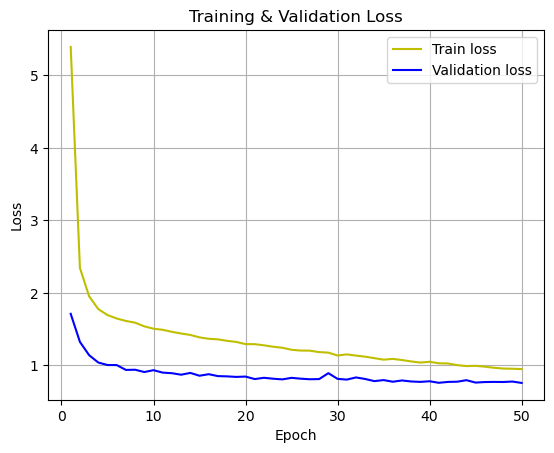

In [47]:
print(history.history.keys()) 

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]  

epochs = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt
plt.plot(epochs, train_loss, "y-", label="Train loss")
plt.plot(epochs, val_loss,   "b-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True); plt.show()

In [48]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ P_matrix            │ (None, 6, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 64)     │        384 │ P_matrix[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 64)     │        128 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embd (PosEmbd)  │ (None, 6, 64)     │        384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_expand_layer   │ (None, 1, 1, 6)   │          0 │ mask[0][0]        │
│ (MaskExpandLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 6, 64)     │     83,200 │ pos_embd[0][0],   │
│ (TransformerEncode… │                   │            │ mask_expand_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 64)     │     83,200 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ mask_expand_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 6, 64)     │     83,200 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ mask_expand_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 6, 1)      │          0 │ mask[0][0]        │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6, 64)     │          0 │ transformer_enco… │
│                     │                   │            │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_1 (Sum)         │ (None, 1)         │          0 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ sum_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalars             │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 64)        │          0 │ sum[0][0],        │
│ (TrueDivide)        │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 25)        │         51 │ scalars[0][0]     │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 89)        │          0 │ true_divide[0][0… │
│ (Concatenate)       │                   │            │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     11,520 │ concatenate[0][0

 Total params: 786,488 (3.00 MB)

 Trainable params: 262,145 (1.00 MB)

 Non-trainable params: 51 (208.00 B)

 Optimizer params: 524,292 (2.00 MB)

In [49]:
model.save("model_2_transformer.keras")


## 2.2. Dense layer

In [14]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split

def padding_one_P(P, k, n=9):
    P = np.asarray(P, np.float32)
    P_ = np.zeros((6, 5), dtype=np.float32)
    P_[:k, :n - k] = P
    return P_

def prepare_features(nkmP_list, mheights):
    X, y = [], []
    for (n, k, m, P), mh in zip(nkmP_list, mheights):
        P_pad = padding_one_P(P, k, n)        # (6,5)
        P_feats = extract_P_features(P_pad)   
        x_vec = np.concatenate(([n, k, m], P_feats, P_pad.flatten()))
        y_val = np.log2(mh)       
        X.append(x_vec)
        y.append(y_val)
    return np.array(X, np.float32), np.array(y, np.float32)



In [52]:
# nkmP_train, nkmP_val, mh_train, mh_val, make sure for both models, the training and val data sets are the samme

X_train_teacher, y_train_teacher = prepare_features(nkmP_train, mh_train)
X_val_teacher, y_val_teacher = prepare_features(nkmP_val, mh_val)


my_X, my_y = prepare_features(my_nkmP, my_mh)
#merge 2 datasets, validation data is from teacher.

X_train = np.vstack([X_train_teacher, my_X])
y_train = np.concatenate([y_train_teacher, my_y])

X_valid = X_val_teacher
y_valid = y_val_teacher

print(f"Teacher raw split:")
print(f"  Train: {len(nkmP_train)}, Val: {len(nkmP_val)}")

print(f"Processed shapes:")
print(f"  X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"  X_valid = {X_valid.shape}, y_valid = {y_valid.shape}")


Teacher raw split:
  Train: 45092, Val: 11273
Processed shapes:
  X_train = (83716, 55), y_train = (83716,)
  X_valid = (11273, 55), y_valid = (11273,)


In [53]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Dropout
from tensorflow.keras import layers,regularizers

norm = layers.Normalization()  
norm.adapt(X_train) 
# input data being normalized
#the inputs have been flattened and concatenated, so the shape is 1+1+12 features + 6*5 = 55
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  
    norm, 
    layers.Dense(512,kernel_regularizer=regularizers.l2(1e-5)),
    layers.Activation('relu'),

    layers.Dropout(0.3),
    layers.Dense(128,kernel_regularizer=regularizers.l2(1e-5)),
    
    layers.Activation('relu'),

    layers.Dropout(0.3),
    layers.Dense(1, activation='linear')  
])
optimizer = keras.optimizers.AdamW(
    learning_rate=2e-4, # tried 3e-4,1e-4
    weight_decay=1e-5,
    clipnorm=1.0
)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae','mse'])

history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
          epochs=100, batch_size=64,
          callbacks=[keras.callbacks.EarlyStopping(
              monitor='val_loss', patience=10, restore_best_weights=True)])

Epoch 1/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 2s 937us/step - loss: 5.5420 - mae: 1.5626 - mse: 5.5388 - val_loss: 1.4806 - val_mae: 0.8782 - val_mse: 1.4774
Epoch 2/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 2.1343 - mae: 1.0863 - mse: 2.1311 - val_loss: 1.2128 - val_mae: 0.7848 - val_mse: 1.2096
Epoch 3/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - loss: 1.9237 - mae: 1.0240 - mse: 1.9205 - val_loss: 1.1094 - val_mae: 0.7346 - val_mse: 1.1062
Epoch 4/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 1.8146 - mae: 0.9900 - mse: 1.8114 - val_loss: 1.0902 - val_mae: 0.7199 - val_mse: 1.0871
Epoch 5/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - loss: 1.7197 - mae: 0.9617 - mse: 1.7165 - val_loss: 1.0211 - val_mae: 0.7020 - val_mse: 1.0179
Epoch 6/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 1.6696 - mae: 0.9433 - mse: 1.6665 - val_loss: 1.0084 - val_mae: 0.6922 - val_mse: 1.0052
Epoch 7/100
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - loss: 1.614

In [54]:
model.save('model_1_dense.keras')

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])


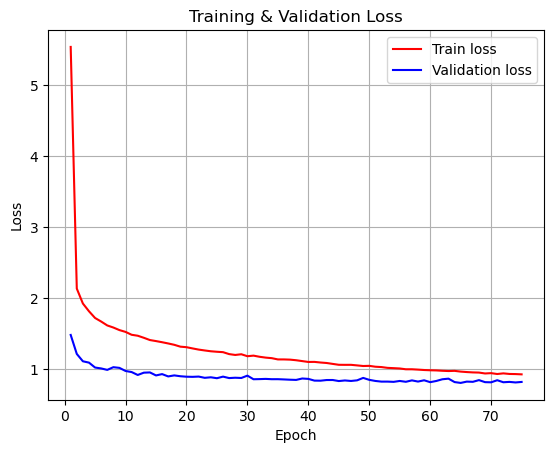

In [55]:
print(history.history.keys()) 

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]  

epochs = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt
plt.plot(epochs, train_loss, "r-", label="Train loss")
plt.plot(epochs, val_loss,   "b-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True); plt.show()

## 2.3 Stacking

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, Model

transformer_model = tf.keras.models.load_model(
    "model_2_transformer.keras",
    custom_objects={
        "PositionalEmbedding": PosEmbd,
        "TransformerEncoder": TransformerEncoder,
        "MaskExpandLayer": MaskExpandLayer
    }
)



/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer

In [58]:
dense_model = tf.keras.models.load_model("model_1_dense.keras")

In [59]:
p_dense_val = dense_model.predict(X_val_teacher, batch_size=256)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step


In [60]:
p_trans_val = transformer_model.predict(
    {"P_matrix": P_val_teacher,
     "mask": mask_val_teacher,
     "scalars": scal_val_teacher},
    batch_size=256
)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [61]:

X_meta = np.concatenate([p_dense_val, p_trans_val], axis=1) #(batch_size, 2)

y_meta = y_val_teacher


In [62]:
from tensorflow.keras.callbacks import EarlyStopping


inp = layers.Input(shape=(2,))
x = layers.Dense(64, activation='relu')(inp)
x = layers.Dense(8, activation='relu')(x)
out = layers.Dense(1)(x)

meta_mlp = Model(inp, out)
optimizer = keras.optimizers.Adam(learning_rate= 2e-4)
meta_mlp.compile(optimizer= optimizer, loss='mse')

early = EarlyStopping(patience=10, restore_best_weights=True)

meta_mlp.fit(
    X_meta, y_meta,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early]
)


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 30.3754 - val_loss: 11.6720
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step - loss: 4.8284 - val_loss: 1.1485
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 0.8496 - val_loss: 0.6648
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 0.7482 - val_loss: 0.6651
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 0.7480 - val_loss: 0.6647
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 0.7475 - val_loss: 0.6652
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - loss: 0.7475 - val_loss: 0.6635
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - loss: 0.7468 - val_loss: 0.6637
Epoch 9/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 0.7467 - val_loss: 0.6626
Epoch 10/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - loss: 0.7465 - val_loss: 0.6635
Epoch 11/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 0.7454 - val_loss: 0.6622
Epoch 12/100
141/

In [63]:
meta_mlp.save('model_3_meta.keras')
# p_dense_test = dense_model.predict(X_test_dense, batch_size=256)


# 3. Summary

This project focuses on building a regression model to predict the m-height value from tabular input data. The core modeling strategy combines two different neural architectures — a Dense (fully connected) network and a Transformer-based network—and integrates them through a stacked training scheme. The outputs from both models are merged and passed through an additional two-layer Dense head, allowing the combined system to achieve performance that exceeds the capability of either individual model.

Two additional components are crucial to the final model’s success. First, during data preprocessing, manually engineered features extracted from the numerical patterns of the P matrix were included to provide the model with additional structural signals. Secondly, a much larger training dataset was constructed using an LP–based algorithm, which shows that neural networks benefit substantially from the expanded dataset, confirming that increased data volume leads to more stable and accurate predictions.

Due to space limitations, not all hyperparameter trials are documented in detail. However, the parameters reported in the write-up reflect the near-optimal configuration found through systematic tuning. The explored hyperparameters include (but are not limited to) the number of layers, number of neurons per layer, dropout rates, learning rate choices, and different optimizers.

## 4.testdataset

In [16]:
import pickle
import numpy as np
import tensorflow as tf
from tqdm import tqdm
test_file = "DS-3-Test-n_k_m_P" 
with open(test_file, "rb") as f:
    test_nkmP = pickle.load(f) 

## 4.1 transformer

In [19]:
max_k = 6
max_feat = 5

def preprocess_inference(inputs):
    P_list, mask_list, scalars_list = [], [], []

    for (n, k, m, P) in tqdm(inputs):
        k_i, feat_i = P.shape

        P_pad = np.zeros((max_k, max_feat), dtype=np.float32)
        P_pad[:k_i, :feat_i] = P

        mask = np.zeros(max_k, dtype=np.float32)
        mask[:k_i] = 1.0

        P_feats = extract_P_features(P)
        scalars = np.array([n, k, m] + P_feats, dtype=np.float32)

        P_list.append(P_pad)
        mask_list.append(mask)
        scalars_list.append(scalars)

    return (
        np.array(P_list, dtype=np.float32),
        np.array(mask_list, dtype=np.float32),
        np.array(scalars_list, dtype=np.float32)
    )


In [21]:
P_test, mask_test, scal_test = preprocess_inference(test_nkmP)


100%|█████████████████████████████████████| 14185/14185 [00:04<00:00, 3052.74it/s]


In [33]:
model2 = tf.keras.models.load_model(
    "model_2_transformer.keras",
    custom_objects={
        "PosEmbd": PosEmbd,
        "TransformerEncoder": TransformerEncoder,
        "MaskExpandLayer": MaskExpandLayer,
    }
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer

In [35]:
pred_log2_transformer = model2.predict(
    {"P_matrix": P_test, "mask": mask_test, "scalars": scal_test}
)


444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [57]:
print("min:", np.min(pred_log2_transformer))
print("max:", np.max(pred_log2_transformer))
print("mean:", np.mean(pred_log2_transformer))

min: -2.0000634
max: 17.805096
mean: 8.843083


## 4.1 Dense

In [79]:
test_X_dense = []
for (n, k, m, P) in test_nkmP:
    P_pad = padding_one_P(P, k, n) 
    P_feats = extract_P_features(P_pad)
    x_vec = np.concatenate(([n, k, m],P_feats,P_pad.flatten()))  
    test_X_dense.append(x_vec)
    
test_X_dense = np.array(test_X_dense, dtype=np.float32)
print("Shape of test data:", test_X_dense.shape)

Shape of test data: (14185, 55)


In [80]:
model1 = tf.keras.models.load_model('model_1_dense.keras')

In [81]:
pred_log2_dense = model1.predict(test_X_dense).squeeze()

444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 218us/step


In [82]:
print("min:", np.min(pred_log2_dense ))
print("max:", np.max(pred_log2_dense ))
print("mean:", np.mean(pred_log2_dense ))

min: 2.1394725
max: 16.767694
mean: 8.775891


## merge

In [87]:
meta_model = tf.keras.models.load_model('model_3_meta.keras')

In [89]:
pred_log2_dense = np.reshape(pred_log2_dense, (-1, 1))
pred_log2_transformer = np.reshape(pred_log2_transformer, (-1, 1))

X_meta = np.concatenate([pred_log2_dense,pred_log2_transformer], axis = 1)

In [91]:
y_pred_log2 = meta_model.predict(X_meta)

444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 170us/step


In [93]:
print("min:", np.min(y_pred_log2))
print("max:", np.max(y_pred_log2))
print("mean:", np.mean(y_pred_log2))


min: 1.7396188
max: 17.21383
mean: 8.7959585


In [99]:
y_pred = np.power(2, y_pred_log2)

In [103]:
print("min",np.min(y_pred), "max",np.max(y_pred))

min 3.3394692 max 152012.55


In [97]:
output_filename = "CSCE 636-600 Fall 2025 Project 3 Test Results Xiaoyun Chu UIN231002795.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(list(y_pred), f)

print("✅ Saved predictions to:", output_filename)

✅ Saved predictions to: CSCE 636-600 Fall 2025 Project 3 Test Results Xiaoyun Chu UIN231002795.pkl


In [105]:
print(y_pred[0])

[57.810097]


In [107]:
print(test_nkmP[0])

[9, 4, 4, array([[-31.,  30.,  38.,  29., -40.],
       [ 49., -23., -39., -32.,  48.],
       [-41.,  23.,  50.,  18., -39.],
       [ 56., -37., -53., -36.,  62.]])]


In [109]:
print(y_pred[10])

[25.648403]


In [111]:
print(test_nkmP[10])

[9, 4, 3, array([[-8.,  3., -2.,  3., -5.],
       [ 1.,  3., -3., -1.,  7.],
       [ 3., -2.,  1., -1.,  1.],
       [-3.,  3.,  9., -3.,  0.]])]
